In [99]:
from get_stock_data import get_combined_tech_stocks
from get_normalized_price import get_normalized_prices
import numpy as np
import pandas as pd
from datetime import date, timedelta, datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
tech_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]
data = get_combined_tech_stocks(tech_tickers)

Fetching data from 2011-07-10 to 2026-07-06...


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [101]:
def get_history_and_target_price(target_ticker, window=50):
    target_price = get_normalized_prices(data, target_ticker)[:window]
    history_prices = {}
    for ticker in data.keys():
        history_prices[ticker] = get_normalized_prices(data, ticker)[window:]
    return target_price, history_prices

In [102]:
target_price, historical_prices = get_history_and_target_price("AAPL", 50)

In [103]:
def compute_dtw_matrix(x, y, window=5):
    N, M = len(x), len(y)
    # Initialize with Infinity
    dtw_matrix = np.full((N + 1, M + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Sakoe-Chiba constraint band
    w = max(window, abs(N - M))
    
    for i in range(1, N + 1):
        # Only calculate within the diagonal band
        for j in range(max(1, i - w), min(M + 1, i + w + 1)):
            cost = abs(x[i - 1] - y[j - 1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i - 1, j],    # insertion
                dtw_matrix[i, j - 1],    # deletion
                dtw_matrix[i - 1, j - 1] # match
            )
    return dtw_matrix

def compare_dtw_patterns(target_pattern, historical_prices, price_window=50, dtw_window=5):
    """
    Compares a SINGLE target price pattern against all historical prices.
    """
    results = []
    
    # Extract just the numeric price data for the SINGLE target pattern
    t_seq = target_pattern[:price_window]
    t_dates = target_pattern[-2] 
    
    # Iterate through all tickers in the historical dictionary
    for ticker, hist_patterns in historical_prices.items():
        for h_idx, hist_pattern in enumerate(hist_patterns):
            
            # Extract just the numeric price data and metadata for the historical pattern
            h_seq = hist_pattern[:price_window]
            h_future_change = hist_pattern[-3]
            h_dates = hist_pattern[-2]
            
            # Compute the matrix using your DTW function
            dtw_mat = compute_dtw_matrix(t_seq, h_seq, window=dtw_window)
            
            # The DTW distance score is the bottom-right value of the matrix
            dtw_distance = dtw_mat[-1, -1]
            
            results.append({
                "historical_ticker": ticker,
                "historical_dates_end": h_dates[0].strftime('%Y-%m-%d'),
                "historical_dates_start": h_dates[1].strftime('%Y-%m-%d'),
                "dtw_distance": dtw_distance,
                "future_change_%": round(h_future_change * 100, 2),
                "prices": h_seq
            })

            
    # Sort the results so the closest DTW matches (lowest distance) appear first
    sorted_results = sorted(results, key=lambda x: x["dtw_distance"])
    return sorted_results

def get_top_matches(target_pattern, historical_prices, price_window=50, dtw_window=5, n_top_match=10, blackout_window=50):
    sorted_results = compare_dtw_patterns(target_pattern, historical_prices, price_window, dtw_window)

    top_matches = []

    for result in sorted_results:
        historical_date_end = datetime.strptime(result["historical_dates_end"], "%Y-%m-%d").date()

        if len(top_matches) > n_top_match:
            break
        
        add_date = True

        for matched in top_matches:
            matched = datetime.strptime(matched["historical_dates_end"], "%Y-%m-%d").date() 

            if historical_date_end < matched + timedelta(days=blackout_window) and historical_date_end > matched - timedelta(days=blackout_window):
                add_date = False

        if add_date:
            top_matches.append(result)

    return top_matches

In [131]:
top_matches = get_top_matches(target_price[0], historical_prices, price_window=50, dtw_window=8, n_top_match=20, blackout_window=30)

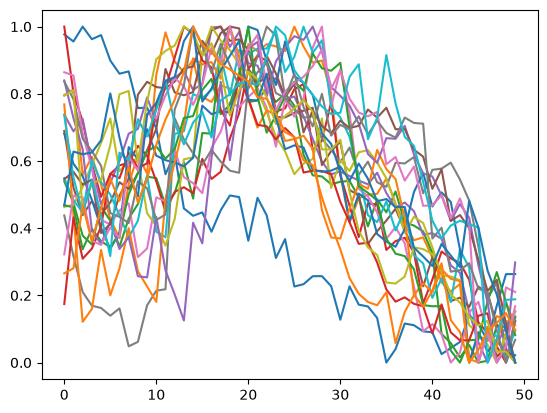

In [132]:
plt.plot(target_price[30][:50])
# plt.plot(top_matches[0]["prices"])
# plt.plot(top_matches[1]["prices"])

for match in top_matches:
    plt.plot(match["prices"])
# plt.plot(top_matches[2]["prices"])

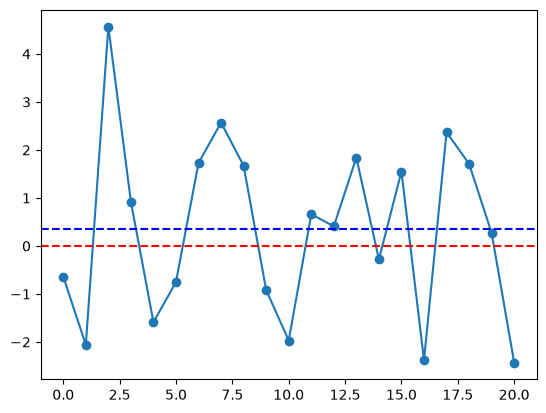

In [ ]:
a = []
for match in top_matches:
    a.append(match["future_change_%"])

plt.scatter(np.arange(len(a)), a)
plt.plot(np.arange(len(a)), a)
plt.axhline(y=np.mean(a), color='blue', linestyle='--')
plt.axhline(y=target_price[30][-3], color='red', linestyle='--')




In [130]:
top_matches[0]

{'historical_ticker': 'META',
 'historical_dates_end': '2024-01-26',
 'historical_dates_start': '2023-11-14',
 'dtw_distance': np.float64(1.668890464917529),
 'future_change_%': np.float64(-2.12),
 'prices': [1.0,
  0.9874826381919634,
  0.9551447151860624,
  0.8834274015495163,
  0.8388322427843121,
  0.8606089679258159,
  0.7651587652041267,
  0.6639717393922364,
  0.6521062984223837,
  0.7437738348520734,
  0.6809236883304565,
  0.6913548231704869,
  0.5213194974107824,
  0.5373585966039099,
  0.44986351411023245,
  0.38688210027698605,
  0.3523278872787122,
  0.3760599735056802,
  0.47607322066556945,
  0.5329244109028141,
  0.5265352655453415,
  0.4874160009634298,
  0.46864076110955,
  0.4777672514150375,
  0.41504716791778734,
  0.42912970173818793,
  0.35428364979326404,
  0.2277997671711292,
  0.2049817349765164,
  0.22545301272530208,
  0.2186724740074666,
  0.10209907269880776,
  0.19950463650596123,
  0.11918028180321946,
  0.0,
  0.010952992653847698,
  0.03351049737063948

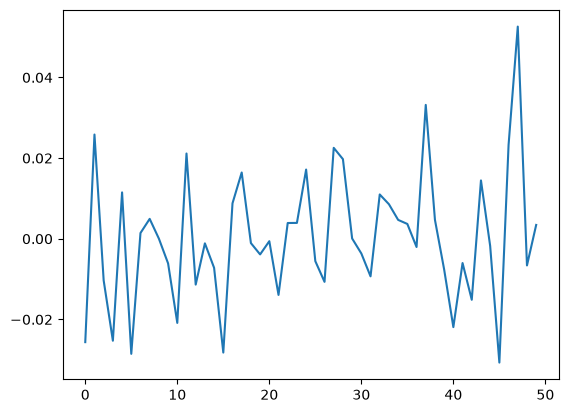

In [143]:
b = []

for p in target_price:
    b.append(p[-3])

plt.plot(np.arange(len(b)), b)
